# FAI Coursework Two -2025
# Introduction

The questions are based on the machine learning algorithms covered in labs. Students are expected to identify the correct syntax to import modules and call functions. Students are also expected to evaluate the performance of different algorithms. 

# Marks

Coursework 2 accounts for 10% of the COMP1037 marks. Corresponding marks will be awarded for answering each of the sub-questions. 

1. Answer questions using `Markdown` cell.
2. Use `Code` cell to input your code. 
**Note: (a). please run your code in the notebook and upload your notebook together with all the outputs. (b). avoid using problem setting requires more than 3 mins to get the output. (c). Please only import the packages in <font color=red>sklearn pandas matplotlib </font> or as the question requirement. (d). If you import other external packages, we will remove that and mark your code with the remaining code.(e). You can use multiple code cells and markdown cells for each question. **


# Plagiarism vs. Group Discussions

As you should know, there is no tolerance of plagiarism, and any breach of which will be dealt with according to the University's standard policies. Please be very careful not to cross the boundary into plagiarism while having general discussions regarding the coursework to promote the generation of new ideas and to enhance the learning experience. The important part is that when you sit down to actually do the work and write the answers, you do it individually. If you do this, and you truly understand what you have written, you will not be guilty of plagiarism. Do NOT, under any circumstances, share code or share figures, graphs or charts, etc.

# Deadline and submission procedure 

## <span style="background-image: linear-gradient(to right, #FF22AA, #FF9264, #FFFF66, #64FFB4, #00A2FF); font-weight:bold; color:white; text-shadow: -1px 0 black, 0 1px black, 1px 0 black, 0 -1px black;">20 marks deducted for not submitting as required！</span>
The submission deadline is 11:59pm on the <font color=red> **9th  May 2025** </font> via Moodle. Late submission results into a 5% reduction of your coursework mark for each day. Any work handed in after the 11:59pm of 13th May will receive <font color=red> **zero marks**.

Name your submission file: <font color=red>FAICW2-XXX.ipynb</font>, where XXX should be your student ID number, for instance, FAICW2-20515678.ipynb, and submit a single file via Moodle.

If you can’t submit your coursework on time due to Extenuating Circumstances, please contact your personal tutor first. I am only granting an extension of submission based on his / her recommendation.

## Part I. Clustering and Classification
Answer the following questions related to the grocery store transaction data. Below is the database schema. 

<img src='.\Table_scheme.jpg' width=50%>

Perform data-preprocessing:
* Load all necessary data
* Fill missing data



In [3]:

# ----------------------------- #
# Part I – Data Loading & Cleaning
# ----------------------------- #
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns

from pathlib import Path

DATA_DIR = Path('Data')  # folder that contains the CSV files

customer_survey = pd.read_csv(DATA_DIR / 'customer_survey.csv')
sales            = pd.read_csv(DATA_DIR / 'sales.csv')
transactions     = pd.read_csv(DATA_DIR / 'transactions.csv')
items            = pd.read_csv(DATA_DIR / 'items.csv')

# Make a working copy of the customer‑level demographics
customer_df = customer_survey.copy()

# ------------------------------------------------------------------
# 1) Normalise / encode categorical columns so that we can feed them
#    into clustering / classification models later on.
# ------------------------------------------------------------------
# Sex → binary
customer_df['Cust_Sex'] = customer_df['Cust_Sex'].map({'M': 0, 'F': 1})

# Relationship status → binary
customer_df['Cust_Rel_Status'] = customer_df['Cust_Rel_Status'].map({'Single': 0, 'Married': 1})

# Age bracket → mid‑point of range
age_midpoint = {'18-24': 21, '25-44': 34.5, '45-64': 54.5, '65+': 70}
customer_df['Cust_Age'] = customer_df['Cust_Age'].map(age_midpoint)

# Children → binary
child_map = {'Has_no_Child(ren)': 0, 'Has_child(ren)': 1}
customer_df['Cust_Children'] = customer_df['Cust_Children'].map(child_map)

# ------------------------------------------------------------------
# 2) Replace any residual missing values with sensible defaults
# ------------------------------------------------------------------
num_cols = ['Cust_Income', 'Cust_Age']
cat_cols = ['Cust_Sex', 'Cust_Rel_Status', 'Cust_Children']

for col in num_cols:
    customer_df[col] = customer_df[col].fillna(customer_df[col].median())

for col in cat_cols:
    customer_df[col] = customer_df[col].fillna(0)  # most common / default

print('Demographic data prepared – preview:')
display(customer_df.head())


Demographic data prepared – preview:


,Customer_ID,Cust_Sex,Cust_Income,Cust_Race,Cust_Age,Cust_Children,Cust_Rel_Status
0,7366,0.0,50600,White,34.5,0.0,1.0
1,11947,0.0,82900,White,34.5,0.0,1.0
2,12872,0.0,100400,White,34.5,0.0,1.0
3,14392,0.0,64900,White,34.5,0.0,1.0
4,16347,0.0,69400,White,54.5,0.0,1.0




## Data pre-processing and Feature preparation:
Add the following three features to the 'customer_df' data defined abover:
* Number of trips: The number of trips a customer visits a store and make a transaction.
* Average sale price: The average spending price of a customer's transactions, which is $\frac{\text{Total revenue of all transactions for a customer}}{\text{Number of trips}}$ .
* Average item price: The average item price for a customer's transactions, which is $\frac{\text{Total revenue of all transactions for a customer}}{\text{Total number of items in all those transactions}}$.

 

In [4]:
# ───────────────────────────────────────────────────────────────
# 1)  Merge Price_Per_Item to transactions
# ───────────────────────────────────────────────────────────────
trans_enriched = (
    transactions
      .merge(items[["Item_ID", "Price_Per_Item"]], on="Item_ID", how="left")
)

# calculate revenue of a line of sale_ID
trans_enriched["Line_Total"] = (
   (1-trans_enriched["Item_Discount"])* trans_enriched["Price_Per_Item"] * trans_enriched["Amount_Purchased"]
   
)

# ───────────────────────────────────────────────────────────────
# 2)  Sale_ID groupby
#     * CountItems  = the number of items in the sale_ID
#     * SalePrice   = The total price of the sale_ID
# ───────────────────────────────────────────────────────────────
sale_totals = (
    trans_enriched.groupby("Sale_ID", as_index=False)
                  .agg(
                      SalePrice  = ("Line_Total",        "sum"),
                      CountItems = ("Amount_Purchased",  "sum")
                  )
)

# ───────────────────────────────────────────────────────────────
# 3)  Bring in Customer_ID → Aggregate at Customer level
# ───────────────────────────────────────────────────────────────
sale_level = (
    sales[["Sale_ID", "Customer_ID"]]
        .merge(sale_totals, on="Sale_ID")
)

cust_metrics = (
    sale_level.groupby("Customer_ID", as_index=False)
              .agg(
                  Avg_Count_Items = ("CountItems", "mean"),
                  Total_Items     = ("CountItems", "sum"),
                  Avg_Sale_Price  = ("SalePrice",  "mean"),
                  Total_Revenue   = ("SalePrice",  "sum"),
                  Num_Trips       = ("Sale_ID",    "size"),
              )
)

# Avg_Item_Price = Total_revenue/Total item
cust_metrics["Avg_Item_Price"] = (
    cust_metrics["Total_Revenue"] / cust_metrics["Total_Items"]
)

# ───────────────────────────────────────────────────────────────
# 4)  Merge to customer_features
# ───────────────────────────────────────────────────────────────
customer_features = (
    customer_df
      .merge(cust_metrics[["Customer_ID",
                           "Num_Trips",
                           "Avg_Sale_Price",
                           "Avg_Item_Price"]],
             on="Customer_ID", how="left")
      .fillna(0)
)

print("Combined customer feature set – preview:")
display(customer_features.head())

Combined customer feature set – preview:


,Customer_ID,Cust_Sex,Cust_Income,Cust_Race,Cust_Age,Cust_Children,Cust_Rel_Status,Num_Trips,Avg_Sale_Price,Avg_Item_Price
0,7366,0.0,50600,White,34.5,0.0,1.0,10.0,147.502200,3.772435
1,11947,0.0,82900,White,34.5,0.0,1.0,12.0,217.783833,3.977787
2,12872,0.0,100400,White,34.5,0.0,1.0,12.0,209.350333,4.104908
3,14392,0.0,64900,White,34.5,0.0,1.0,2.0,169.212000,3.802517
4,16347,0.0,69400,White,54.5,0.0,1.0,9.0,184.746889,3.977804


[10 marks] 1. Draw three scatter plots of:

* customer income vs. Number of trips, 
* customer income vs. Average sale price, 
* customer income vs. Average item price.  

Present your plots within a 2x2 subplots layout and explain the relationship between the three pairs.

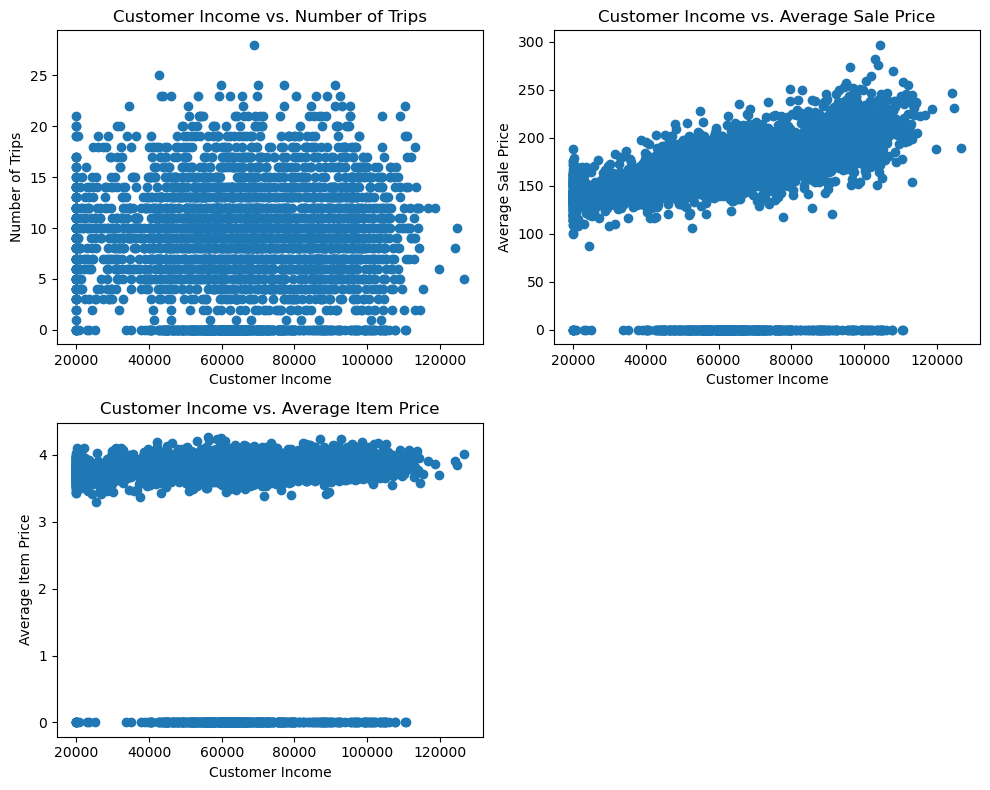

In [5]:
# create 2x2 subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# customer income vs. Number of trips
axs[0, 0].scatter(customer_features['Cust_Income'], customer_features['Num_Trips'])
axs[0, 0].set_xlabel('Customer Income')
axs[0, 0].set_ylabel('Number of Trips')
axs[0, 0].set_title('Customer Income vs. Number of Trips')

# customer income vs. Average sale price
axs[0, 1].scatter(customer_features['Cust_Income'], customer_features['Avg_Sale_Price'])
axs[0, 1].set_xlabel('Customer Income')
axs[0, 1].set_ylabel('Average Sale Price')
axs[0, 1].set_title('Customer Income vs. Average Sale Price')

# customer income vs. Average item price
axs[1, 0].scatter(customer_features['Cust_Income'], customer_features['Avg_Item_Price'])
axs[1, 0].set_xlabel('Customer Income')
axs[1, 0].set_ylabel('Average Item Price')
axs[1, 0].set_title('Customer Income vs. Average Item Price')

# hide the fourth subplot
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()

### 1. Customer Income vs. Number of Trips
- **Relationship Analysis**: Judging from the scatter plot, as the customer income (Customer Income) increases, the number of shopping trips (Number of Trips) does not show an obvious upward or downward trend. The scatter points are relatively scattered without a clear clustering direction. This indicates that there may not be a strong correlation between the customer's income level and the number of trips to the grocery store. There may be various factors influencing the number of shopping trips, such as the distance between the customer's residence and the store, personal shopping habits, and whether they like to stock up, making the impact of income on the number of trips insignificant. 

### 2. Customer Income vs. Average Sale Price
- **Relationship Analysis**: The scatter plot shows a clear trend from the lower left to the upper right, that is, as the customer income (Customer Income) increases, the average spending per shopping trip (Average Sale Price) also increases. This indicates that customers with higher incomes tend to spend more per shopping trip, and there is a strong positive correlation between the two. A possible reason is that high - income customers are less price - sensitive and are more willing to buy high - quality, high - priced products, or purchase more items at once, thus increasing the average consumption amount per shopping trip. 

### 3. Customer Income vs. Average Item Price
- **Relationship Analysis**: The scatter points in the scatter plot are relatively concentrated in the direction of the average item price (Average Item Price). As the customer income (Customer Income) changes, the average item price does not show an obvious trend of change. This shows that the correlation between the customer income level and the average unit price of the purchased items is weak. Although high - income customers theoretically have more ability to buy high - priced products, the actual data shows that there is no obvious difference in the average unit price of items due to income differences. This may be because the price range of items in the grocery store is relatively fixed, or customers, regardless of their income levels, will comprehensively consider factors such as cost - performance when purchasing items.

[20 marks] 2. Select ‌two features‌ from the following for clustering analysis: 
* Number of trips
* Average sale price
* Average item price
* Customer income

Please use the scikit-learn library's KMeans function. The number of clusters (K) can be either pre-specified or determined through optimization methods (e.g., elbow method or silhouette analysis). 

Generate 2D visualization plots to vividly show your clustering results. Given that there are six potential combinations, you need to generate six distinct clustering plots.

D:\ProgramData\anaconda\envs\FAIens\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=14.
  warnings.warn(
D:\ProgramData\anaconda\envs\FAIens\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=14.
  warnings.warn(
D:\ProgramData\anaconda\envs\FAIens\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=14.
  warnings.warn(
D:\ProgramData\anaconda\envs\FAIens\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: 

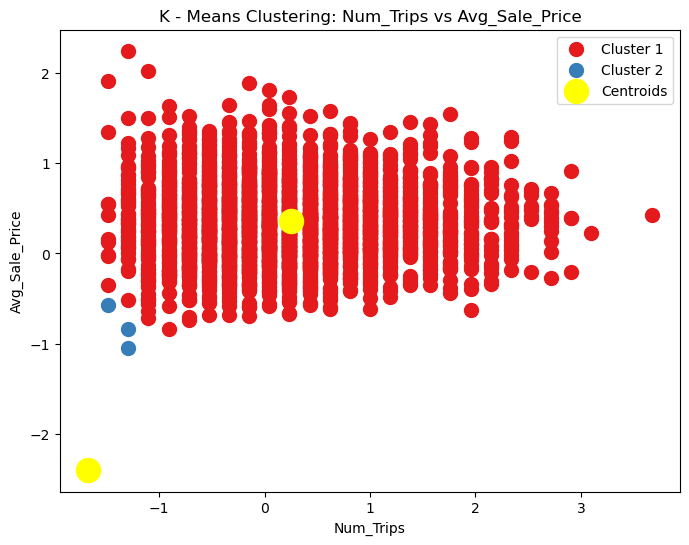

D:\ProgramData\anaconda\envs\FAIens\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=14.
  warnings.warn(
D:\ProgramData\anaconda\envs\FAIens\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=14.
  warnings.warn(
D:\ProgramData\anaconda\envs\FAIens\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=14.
  warnings.warn(
D:\ProgramData\anaconda\envs\FAIens\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: 

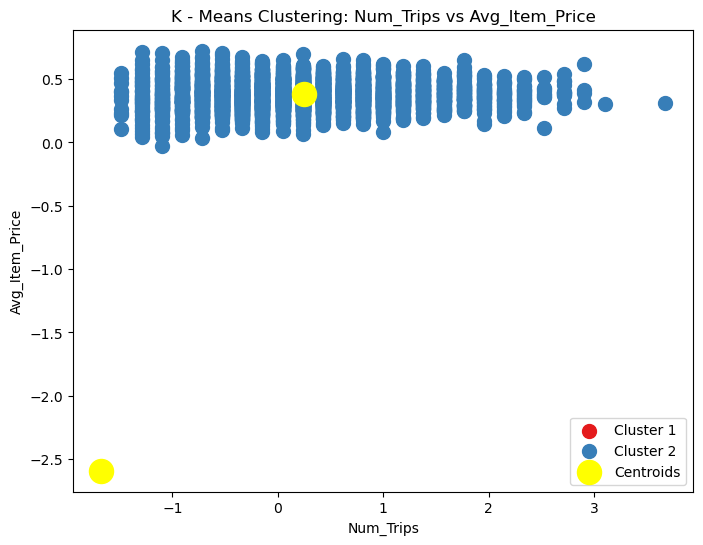

D:\ProgramData\anaconda\envs\FAIens\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=14.
  warnings.warn(
D:\ProgramData\anaconda\envs\FAIens\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=14.
  warnings.warn(
D:\ProgramData\anaconda\envs\FAIens\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=14.
  warnings.warn(
D:\ProgramData\anaconda\envs\FAIens\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: 

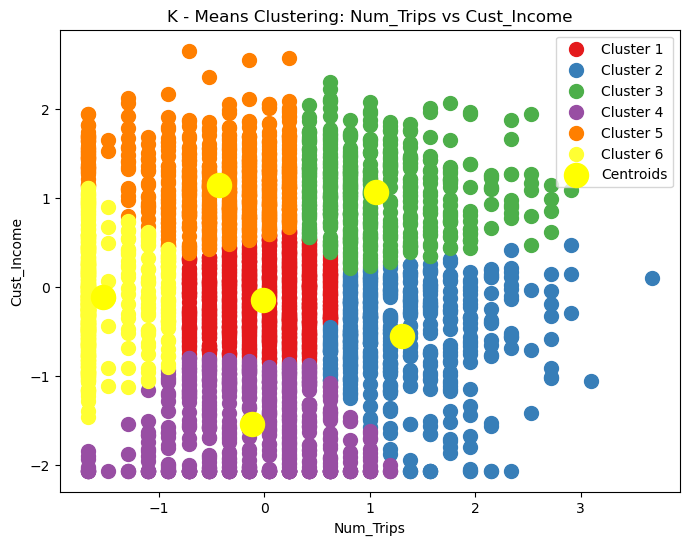

D:\ProgramData\anaconda\envs\FAIens\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=14.
  warnings.warn(
D:\ProgramData\anaconda\envs\FAIens\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=14.
  warnings.warn(
D:\ProgramData\anaconda\envs\FAIens\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=14.
  warnings.warn(
D:\ProgramData\anaconda\envs\FAIens\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: 

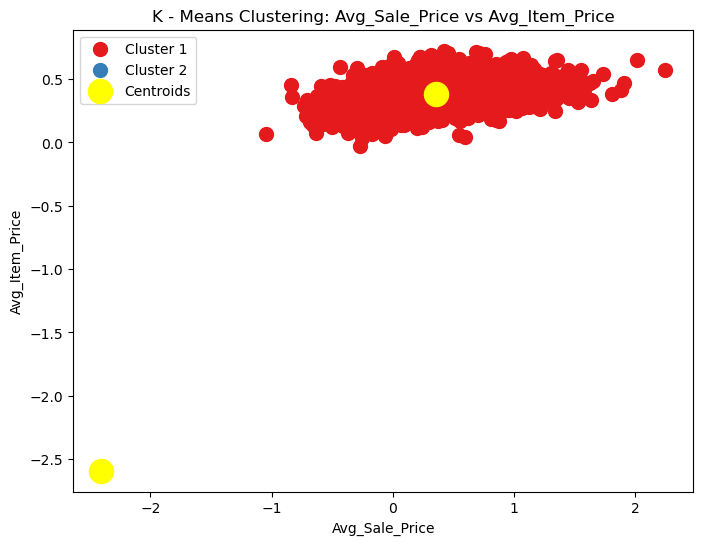

D:\ProgramData\anaconda\envs\FAIens\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=14.
  warnings.warn(
D:\ProgramData\anaconda\envs\FAIens\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=14.
  warnings.warn(
D:\ProgramData\anaconda\envs\FAIens\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=14.
  warnings.warn(
D:\ProgramData\anaconda\envs\FAIens\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: 

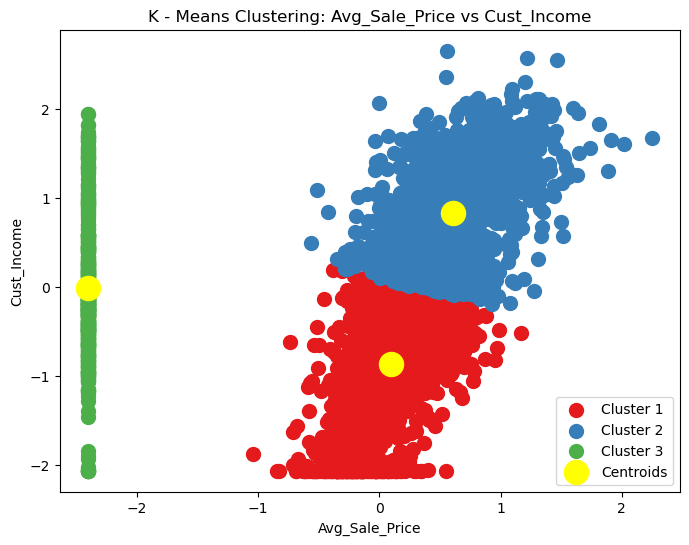

D:\ProgramData\anaconda\envs\FAIens\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=14.
  warnings.warn(
D:\ProgramData\anaconda\envs\FAIens\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=14.
  warnings.warn(
D:\ProgramData\anaconda\envs\FAIens\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=14.
  warnings.warn(
D:\ProgramData\anaconda\envs\FAIens\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: 

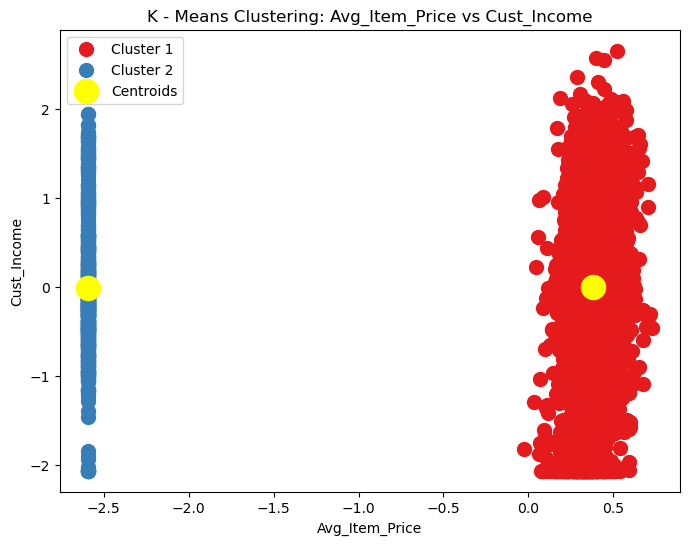

In [6]:
import sklearn
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

def find_optimal_k(X_scaled, min_k=2, max_k=11):
    """
    Determine the optimal number of clusters K using the silhouette analysis
    :param X_scaled: Standardized data
    :param min_k: Minimum number of clusters to try
    :param max_k: Maximum number of clusters to try
    :return: Optimal number of clusters K
    """
    best_score = -1
    optimal_k = min_k
    for k in range(min_k, max_k):
        kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=0)
        labels = kmeans.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        if score > best_score:
            best_score = score
            optimal_k = k
    return optimal_k

def perform_clustering_and_visualization(customer_features, features_combinations):
    """
    Perform K-Means clustering analysis on feature combinations and visualize them
    :param customer_features: Data frame containing features
    :param features_combinations: List of feature combinations
    """
    for combination in features_combinations:
        try:
            X = customer_features[list(combination)].values
            # Feature scaling
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)
            
            optimal_k = find_optimal_k(X_scaled)

            # K - Means clustering
            kmeans = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=0)
            y_kmeans = kmeans.fit_predict(X_scaled)

            plt.figure(figsize=(8, 6))
            for i in range(optimal_k):
                plt.scatter(X_scaled[y_kmeans == i, 0], X_scaled[y_kmeans == i, 1], s=100, color=plt.cm.Set1(i), label=f'Cluster {i + 1}')
            plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, color='yellow', label='Centroids')
            plt.xlabel(combination[0])
            plt.ylabel(combination[1])
            plt.title(f'K - Means Clustering: {combination[0]} vs {combination[1]}')
            plt.legend()
            plt.show()
        except KeyError:
            print(f"Error: One or more features in {combination} are not present in the data.")
        except Exception as e:
            print(f"An unexpected error occurred for {combination}: {e}")


features_combinations = [
    ('Num_Trips', 'Avg_Sale_Price'),
    ('Num_Trips', 'Avg_Item_Price'),
    ('Num_Trips', 'Cust_Income'),
    ('Avg_Sale_Price', 'Avg_Item_Price'),
    ('Avg_Sale_Price', 'Cust_Income'),
    ('Avg_Item_Price', 'Cust_Income')
]
perform_clustering_and_visualization(customer_features, features_combinations)

[20 marks] 3. Apply Principal Component Analysis (PCA) to reduce the dimensionality of the above four features. Then, perform customer clustering using the top two principal components (PCs) via the K-means algorithm. You may either randomly select the value of K or determine an optimal K (e.g., using the elbow method). Visualize the clustering results in a 2D scatter plot based on the two principal components. 


D:\ProgramData\anaconda\envs\FAIens\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=14.
  warnings.warn(
D:\ProgramData\anaconda\envs\FAIens\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=14.
  warnings.warn(
D:\ProgramData\anaconda\envs\FAIens\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=14.
  warnings.warn(
D:\ProgramData\anaconda\envs\FAIens\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: 

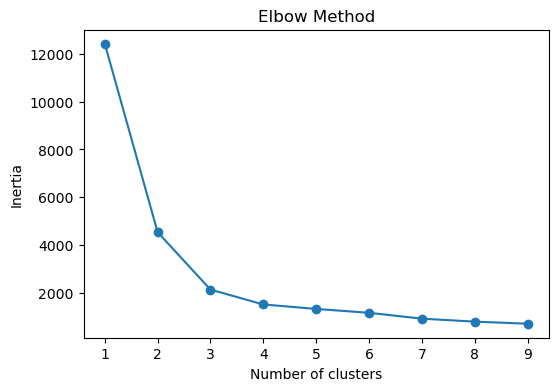

D:\ProgramData\anaconda\envs\FAIens\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=14.
  warnings.warn(


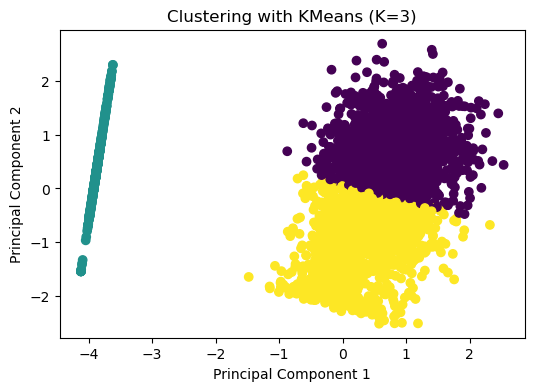

In [7]:
from sklearn.decomposition import PCA

features = ['Num_Trips', 'Avg_Sale_Price', 'Avg_Item_Price', 'Cust_Income']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(customer_features[features])

# reduce the dimensionality
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# using the elbow method
inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# Based on the image
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans.fit(X_pca)
labels = kmeans.labels_

# Visualize the clustering results
plt.figure(figsize=(6, 4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'Clustering with KMeans (K={optimal_k})')
plt.show()

[10 marks] 4. The current dataset does not have labels and cannot be used for classification. In this question, create a labeled dataset using the following requirements:

- Use customer demographic data as features, i.e. 'Cust_Sex', 'Cust_Income', 'Cust_Age', 'Cust_Children', 'Cust_Rel_Status'
- Create a label for each customer based on their average sale price:
    - Low‌: Bottom 1/3 of customers (lowest average sale price)
    - ‌Medium‌: Middle 1/3 of customers
    - ‌High‌: Top 1/3 of customers (highest average sale price)

The dataset is prepared for classification in next question. Display the first few rows of the dataset in ascending order of Customer_ID.



In [8]:
customer_features['Label'] = pd.qcut(customer_features['Avg_Sale_Price'], q=3, labels=['Low', 'Medium', 'High'])
customer_features = customer_features.sort_values(by='Customer_ID')
print(customer_features.head())

   Customer_ID  Cust_Sex  Cust_Income Cust_Race  Cust_Age  Cust_Children  \
0         7366       0.0        50600     White      34.5            0.0   
1        11947       0.0        82900     White      34.5            0.0   
2        12872       0.0       100400     White      34.5            0.0   
3        14392       0.0        64900     White      34.5            0.0   
4        16347       0.0        69400     White      54.5            0.0   

   Cust_Rel_Status  Num_Trips  Avg_Sale_Price  Avg_Item_Price   Label  
0              1.0       10.0      147.502200        3.772435     Low  
1              1.0       12.0      217.783833        3.977787    High  
2              1.0       12.0      209.350333        4.104908    High  
3              1.0        2.0      169.212000        3.802517  Medium  
4              1.0        9.0      184.746889        3.977804    High  


[20 marks]5. Use the dataset created in Question 4，split the data into ‌training and testing sets‌ using train_test_split (e.g., 70-30 or 80-20 split). Select ‌four different classifiers‌, such as:
* ‌Logistic Regression‌
* Decision Tree
* K-Nearest Neighbors
* Neural networks
* Naive Bayes

Evaluate models using the metrics of ‌"Accuracy". Make a conclusion of which model performs the best in a markdown cell.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

X = customer_features[['Cust_Sex', 'Cust_Income', 'Cust_Age', 'Cust_Children', 'Cust_Rel_Status']]
y = customer_features['Label']

# Split the data into ‌training and testing sets‌
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Select ‌four different classifiers‌
classifiers = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Neural Networks': MLPClassifier(max_iter = 500),
}

# Define the hyperparameter grid
param_grids = {
    'Logistic Regression': {'C': [0.1, 1, 10]},
    'Decision Tree': {'max_depth': [3, 5, 7]},
    'K-Nearest Neighbors': {'n_neighbors': [3, 5, 7]},
    'Neural Networks': {'hidden_layer_sizes': [(10,), (20,), (10, 10)]}
}

# Train and evaluate models 
results = {}
for name, clf in classifiers.items():
    grid_search = GridSearchCV(clf, param_grids[name], cv=5)
    grid_search.fit(X_train_scaled, y_train)
    best_clf = grid_search.best_estimator_
    y_pred = best_clf.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy

for name, accuracy in results.items():
    print(f"{name} Accuracy: {accuracy}")

Logistic Regression Accuracy: 0.5486600846262342
Decision Tree Accuracy: 0.5289139633286318
K-Nearest Neighbors Accuracy: 0.5105782792665726
Neural Networks Accuracy: 0.5514809590973202


Among these four models, the neural network has the highest accuracy rate. Therefore, under the setting of this experiment, the neural network model performs the best.

## Part II. Answer the following questions related to the MDP problem.

Customer Loyalty Management MDP

A retailer is managing their customer loyalty program. The problem can be modeled as a Markov Decision Process (MDP) with the following components:

States:
Three possible customer states are considered:
- Active (A): Customers who shop frequently and regularly
- Hesitant (H): Customers whose shopping frequency has declined
- At Risk (R): Customers who haven't shopped for a long time

Actions:
In each state, the retailer can take one of two actions:
- Promote (P): Send coupons or special offers to incentivize purchases
- Maintain (M): Continue with regular service without special promotions

Rewards:
- Active state: +5 (revenue from loyal customers)
- Hesitant state: -1 (potential revenue loss)
- At Risk state: -3 (significant revenue loss)

Initial State:
Let's assume the customer begins in the 'Active' state.

Transition Probabilities:
The transition probabilities and rewards are defined in the diagram below, showing how customers move between states based on the retailer's actions.
The goal is to determine the optimal policy that maximizes the expected long-term customer value, balancing the cost of promotions against the benefit of maintaining customer loyalty.

<img src='.\MDP-customer.svg' width=30%>

### [20 Marks] Calculate the optimal value and optimal policy for each state using epsilon of 0.001 and gamma of 0.9. Print your results. You can define your own value iteration function and MDP or use the functions provided in mdp4e.py.

In [11]:
from mdp4e import *

states = ['A', 'H', 'R']
actions = ['P', 'M']

# Define transitons and rewards
transitions = {
    'A': {
        'P': [(0.3, 'A'), (0.4, 'H'), (0.3, 'R')],
        'M': [(0.5, 'A'), (0.5, 'H')]
    },
    'H': {
        'P': [(0.5, 'A'), (0, 'H'), (0.5, 'R')],
        'M': [(0.4, 'A'), (0.6, 'H')]
    },
    'R': {
        'P': [(0.3, 'A'), (0.3, 'H'), (0.4, 'R')],
        'M': [(0, 'A'), (0.3, 'H'), (0.7, 'R')]
    }
}

rewards = {'A': 5, 'H': -1, 'R': -3}

mdp = MDP(init='A', actlist=actions, terminals=[], transitions=transitions, reward=rewards, states=states, gamma=0.9)

optimal_values = value_iteration(mdp, epsilon=0.001)
print("Optimal Values:")
for state in states:
    print(f"{state}: {optimal_values[state]}")

optimal_policy = best_policy(mdp, optimal_values)
print("\nOptimal Policy:")
for state in states:
    print(f"{state}: {optimal_policy[state]}")

Optimal Values:
A: 20.328641935471715
H: 13.735235342065122
R: 9.68303753986732

Optimal Policy:
A: M
H: M
R: P
